# 07_2. 장애인콜택시 의료 목적지 × 의료기관 분포 분석 — 병원 종별 2그룹·심층·의사수 규모지표

`07_1_medical_destination_analysis_and_insights.ipynb`의 산출물(병원급_총수, 총병상수 등)을 이어받아,
`260906_07_2_피드백반영_계획.md`(v3, 확정)에서 정리한 3가지 신규 분석만 담는다.

## 07_1에서 계승하는 것
- 4개 산출물 CSV(`region_{dong,gu}_call_hospital_combined{,_medical}_병원급규모추가.csv`) — 전체콜/의료목적콜, 병원급 종별 7종, 병상수
- "콜건수"의 정의(목적지 구·동 기준 전체/의료목적 집계 — 의료기관 존재 여부와 무관하게 집계된 값)
- 0건/결측치 구분 원칙: 의료기관이 없는 지역은 0(유효 관측값), 매칭 실패만 NaN

## 신규·보완 분석
- **A**: 병원급 종별(7종)을 그룹1(정신·보건 계열)/그룹2(병원급 의료기관) 2개로 재구성해 비교 (동 단위)
- **B**: 구 단위에서 상급종합병원·종합병원 두 종만 떼어 심층 비교 — 07_1에서 발견된 "동/구 단위 상관 방향 불일치" 재검토
- **C**: 병상수 외에 의사수(`drTotCnt`)를 규모 지표로 추가 — 기관 수 → 병상수 → 의사수 순으로 규모 지표를 바꿔도 관계가 유지되는지 확인
- **D**: 진료과목(재활의학과 등) 데이터 수집 가능성 조사 결과 요약 (실제 조사는 `260906_D1_HIRA_진료과목_API_테스트결과.md`에서 이미 완료됨 — 이 노트북에서 API를 다시 호출하지 않는다)

## 분석 범위
- 팀 다른 노트북(대기시간 06, 인구정규화 01)과의 결합은 이번 범위 밖
- D의 실제 진료과목 전체 수집·구동 집계·콜 데이터 결합(D-5~D-7) — 조사(D-1~D-4)만 완료, 착수는 추후

## 핵심 분석 질문
1. 병원급 종별을 그룹으로 묶어 보면(정신·보건 계열 vs 병원급 의료기관) 콜 건수와의 관계가 개별 종별로 볼 때보다 더/덜 뚜렷한가?
2. 상급종합병원·종합병원의 구 단위 관계가 왜 동 단위와 다르게 나타나는가?
3. 기관 '수' → 병상수 → 의사수로 규모 지표를 바꿔도 콜택시 목적지와의 관계가 유지되는가?
4. 진료과목 구성(재활의학과 등)까지 확보하면 이 관계를 더 설명할 수 있는가? (조사만, 이번 범위 밖 실착수)

**주의**: 이 노트북 전체는 탐색적 상관분석이며, 의료기관 규모가 콜택시 이용을 직접 증가시킨다는 인과관계를 의미하지 않는다.
특히 구 단위 집계에서는 생태학적 오류(ecological fallacy) 가능성이 있고, 동 단위와 구 단위 결과가 다르게 나타나는 것 자체가 공간적 집계 수준에 따른 중요한 관찰일 수 있다.

## 1. 데이터 로드 및 데이터 계약 검증

In [1]:
import platform
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

if platform.system() == "Darwin":
    plt.rcParams["font.family"] = "AppleGothic"
elif platform.system() == "Windows":
    plt.rcParams["font.family"] = "Malgun Gothic"
else:
    plt.rcParams["font.family"] = "NanumGothic"
plt.rcParams["axes.unicode_minus"] = False

pd.set_option("display.max_rows", 60)

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "data").exists() and (PROJECT_ROOT.parent / "data").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

RAW_DIR = PROJECT_ROOT / "data" / "raw"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"

HOSPITAL_GRADE_COLS = ["병원", "종합병원", "요양병원", "상급종합병원", "보건소", "보건지소", "정신병원"]
GROUP1_정신보건계열 = ["정신병원", "보건지소", "보건소"]
GROUP2_병원급의료기관 = ["상급종합병원", "요양병원", "종합병원", "병원"]
GROUP_LABEL_LINE = "그룹1 = 정신병원·보건지소·보건소 / 그룹2 = 상급종합병원·요양병원·종합병원·병원"

print(f"PROJECT_ROOT: {PROJECT_ROOT}")

PROJECT_ROOT: C:\Users\young\my_project\260901_call_taxi_DA


In [2]:
# 07_1 산출물 4종 로드 (원본 컬럼명 보존, 저장용 원본명은 딕셔너리에 기록)
dong_all = pd.read_csv(PROCESSED_DIR / "region_dong_call_hospital_combined_병원급규모추가.csv", encoding="utf-8-sig")
dong_med = pd.read_csv(PROCESSED_DIR / "region_dong_call_hospital_combined_medical_병원급규모추가.csv", encoding="utf-8-sig")
gu_all = pd.read_csv(PROCESSED_DIR / "region_gu_call_hospital_combined_병원급규모추가.csv", encoding="utf-8-sig")
gu_med = pd.read_csv(PROCESSED_DIR / "region_gu_call_hospital_combined_medical_병원급규모추가.csv", encoding="utf-8-sig")

ORIGINAL_CALL_COL = {
    "dong_all": "콜택시_목적지_건수", "gu_all": "콜택시_목적지_건수",
    "dong_med": "콜택시_의료목적지_건수", "gu_med": "콜택시_의료목적지_건수",
}
for name, df in [("dong_all", dong_all), ("gu_all", gu_all), ("dong_med", dong_med), ("gu_med", gu_med)]:
    df.rename(columns={ORIGINAL_CALL_COL[name]: "콜건수"}, inplace=True)

REGION_CALL = {
    ("동", "전체콜"): dong_all, ("동", "의료목적콜"): dong_med,
    ("구", "전체콜"): gu_all, ("구", "의료목적콜"): gu_med,
}

# 저장 전 최종 검증용 — 07_1 산출물이 07_2에서 뒤바뀌지 않았는지 나중에 비교할 기준값
ORIGINAL_SUMS = {
    name: df[["콜건수", "병원급_총수(의원/한의원제외)", "총병상수"]].sum()
    for name, df in [("dong_all", dong_all), ("dong_med", dong_med), ("gu_all", gu_all), ("gu_med", gu_med)]
}
PRE_LEN = {name: len(df) for name, df in [("dong_all", dong_all), ("dong_med", dong_med), ("gu_all", gu_all), ("gu_med", gu_med)]}

for name, df in [("dong_all", dong_all), ("dong_med", dong_med), ("gu_all", gu_all), ("gu_med", gu_med)]:
    call_sum = df["콜건수"].sum()
    grade_sum = df["병원급_총수(의원/한의원제외)"].sum()
    print(f"{name}: {df.shape}, 콜건수 합계 {call_sum:,}, 병원급_총수 합계 {grade_sum:,}")

dong_all: (431, 20), 콜건수 합계 1,369,283, 병원급_총수 합계 440
dong_med: (416, 20), 콜건수 합계 126,705, 병원급_총수 합계 440
gu_all: (25, 19), 콜건수 합계 1,369,283, 병원급_총수 합계 441
gu_med: (25, 19), 콜건수 합계 126,705, 병원급_총수 합계 441


In [3]:
# 의사수(drTotCnt) 원천 데이터 로드 — 05 산출물, P1+P2 9종 전체(14,856행), 07_1의 hosp_ref와 동일 파일
hosp_ref = pd.read_csv(PROCESSED_DIR / "hospital_info_seoul_행정동_파생컬럼추가.csv", encoding="utf-8-sig")
print(f"hosp_ref: {hosp_ref.shape}")
hosp_ref[["yadmNm", "clCdNm", "drTotCnt", "행정동", "sgguCdNm", "ykiho"]].head()

hosp_ref: (14856, 34)


,yadmNm,clCdNm,drTotCnt,행정동,sgguCdNm,ykiho
0,강북삼성병원,상급종합,396,교남동,종로구,JDQ4MTg4MSM1MSMkMSMkMCMkODkkMzgxMzUxIzExIyQxIy...
1,건국대학교병원,상급종합,402,화양동,광진구,JDQ4MTg4MSM1MSMkMSMkMCMkODkkMzgxMzUxIzExIyQxIy...
2,경희대학교병원,상급종합,425,회기동,동대문구,JDQ4MTg4MSM1MSMkMSMkMCMkODkkMzgxMzUxIzExIyQxIy...
3,고려대학교의과대학부속구로병원,상급종합,515,구로2동,구로구,JDQ4MTg4MSM1MSMkMSMkMCMkODkkMzgxMzUxIzExIyQxIy...
4,삼성서울병원,상급종합,1250,일원본동,강남구,JDQ4MTg4MSM1MSMkMSMkMCMkODkkMzgxMzUxIzExIyQxIy...


In [4]:
# 07_1 -> 07_2 데이터 계약 검증 — 07_1 산출물 구조가 나중에 바뀌어도 07_2가 조용히 잘못 도는 것을 방지
EXPECTED_DONG_COLS = {"목적구", "행정동", "콜건수", *HOSPITAL_GRADE_COLS, "의료기관_총수", "병원급_총수(의원/한의원제외)", "총병상수"}
EXPECTED_GU_COLS = {"목적구", "콜건수", *HOSPITAL_GRADE_COLS, "의료기관_총수", "병원급_총수(의원/한의원제외)", "총병상수"}

for name, df, expected in [
    ("dong_all", dong_all, EXPECTED_DONG_COLS), ("dong_med", dong_med, EXPECTED_DONG_COLS),
    ("gu_all", gu_all, EXPECTED_GU_COLS), ("gu_med", gu_med, EXPECTED_GU_COLS),
]:
    missing = expected - set(df.columns)
    assert not missing, f"{name}에 07_2가 기대하는 컬럼이 없음: {missing}"
print("[검증 통과] 07_1 산출물 4종에 07_2가 사용할 핵심 컬럼(콜건수·병원급 종별 7종·병원급_총수·총병상수)이 모두 존재")

required_ref_cols = {"ykiho", "drTotCnt", "행정동", "sgguCdNm", "clCdNm", "yadmNm"}
missing_ref = required_ref_cols - set(hosp_ref.columns)
assert not missing_ref, f"hosp_ref에 필요한 컬럼 없음: {missing_ref}"
print("[검증 통과] 의사수 원천 데이터(hosp_ref)에 필요한 컬럼(ykiho·drTotCnt·행정동·sgguCdNm 등) 모두 존재")

[검증 통과] 07_1 산출물 4종에 07_2가 사용할 핵심 컬럼(콜건수·병원급 종별 7종·병원급_총수·총병상수)이 모두 존재
[검증 통과] 의사수 원천 데이터(hosp_ref)에 필요한 컬럼(ykiho·drTotCnt·행정동·sgguCdNm 등) 모두 존재


## 데이터 출처 및 변수 정의

| 파일 | 설명 | 07_1/07_2 |
|---|---|---|
| `data/processed/region_dong_call_hospital_combined_병원급규모추가.csv` | 전체콜, 행정동 단위 (431행) | 07_1 산출물, read-only |
| `data/processed/region_dong_call_hospital_combined_medical_병원급규모추가.csv` | 의료목적콜, 행정동 단위 (416행) | 07_1 산출물, read-only |
| `data/processed/region_gu_call_hospital_combined_병원급규모추가.csv` | 전체콜, 자치구 단위 (25행) | 07_1 산출물, read-only |
| `data/processed/region_gu_call_hospital_combined_medical_병원급규모추가.csv` | 의료목적콜, 자치구 단위 (25행) | 07_1 산출물, read-only |
| `data/processed/hospital_info_seoul_행정동_파생컬럼추가.csv` | 서울 의료기관(P1+P2, 14,856행) — `drTotCnt`(총 의사수), `ykiho`, `행정동`, `sgguCdNm` 보유 | 05 산출물, 이번에 `drTotCnt` 신규 사용 |
| `data/raw/건강보험심사평가원_의료기관별 감염병 및 중증환자 치료시설 현황_20260630.csv` | 병상수(중환자실·격리병실), 서울 90개 기관만 | 07_1 산출물(총병상수)과의 커버리지 비교용으로 재로드 |

**"콜 건수" 정의(재확인, 07_1 그대로 계승)**

| 변수 | 정의 | 공간단위 | 07_1/07_2 |
|---|---|---|---|
| 전체콜 | 목적지(구/동) 기준, 이용목적 무관 전체 콜 건수 | 동(431)/구(25) | 07_1 계승, 컬럼명 `콜건수`(원본 `콜택시_목적지_건수`) |
| 의료목적콜 | 목적지(구/동) 기준, 이용목적이 {치료·재활·예약치료·예약재활·치료광역}인 콜만 | 동(416)/구(25) | 07_1 계승, 컬럼명 `콜건수`(원본 `콜택시_의료목적지_건수`) |

즉 "콜건수"는 그 지역에 의료기관이 있는지·어떤 종인지와 무관하게 집계된 값이며, 07_2는 이 정의를 재정의하지 않는다.

## 2. A. 병원급 종별 2그룹 비교 (동 단위)

**그룹 정의(확정)**
- **그룹1: 정신·보건 계열** = 정신병원, 보건지소, 보건소
- **그룹2: 병원급 의료기관** = 상급종합병원, 요양병원, 종합병원, 병원

07_1 섹션 3-4에서 병원급 7종을 한 막대그래프에 나열해 개별 종별 Spearman rho를 봤는데, 성격이 다른 기관(공공·특수 목적의
정신·보건 계열과, 일반적인 입원형 병원급 의료기관)이 한 차트에 섞여 있어 해석이 흐려질 수 있다는 피드백을 반영해 2개 그룹으로
나눠 다시 본다. **차트에 그룹명을 짧게 쓸 때는 항상 아래 구성을 함께 표기한다** — 팀원과의 소통에서 그룹명만으로 오해가 생기지
않게 하기 위함이다.

> 그룹1 = 정신병원·보건지소·보건소 / 그룹2 = 상급종합병원·요양병원·종합병원·병원

동 단위만 다룬다(피드백에서 동 단위로 특정함).

In [5]:
# 0건/결측 구분 검증 — 의료기관이 없는 지역(0)과 매칭 실패(NaN)를 구분해서 확인한다.
# 07_1에서 이미 fillna(0) 방식으로 만들어진 컬럼이라 결측 0건이 나오는 게 정상이며, 이걸 노트북에서 재확인해둔다.
rows = []
for region_label, df in [("동 (전체콜)", dong_all), ("동 (의료목적콜)", dong_med)]:
    for col in HOSPITAL_GRADE_COLS:
        rows.append({
            "지역단위": region_label, "종별": col,
            "0건 지역 수": (df[col] == 0).sum(),
            "결측 지역 수": df[col].isnull().sum(),
            "전체 지역 수": len(df),
        })
zero_na_check = pd.DataFrame(rows)
display(zero_na_check)

assert (zero_na_check["결측 지역 수"] == 0).all(), "07_1 산출물에 결측치가 있다 — 확인 필요"
print("[검증 통과] 병원급 7종 모두 결측 0건 — 0은 전부 '해당 종이 실제로 없음'을 의미하는 유효 관측값이며, 상관분석에 그대로 포함한다.")

,지역단위,종별,0건 지역 수,결측 지역 수,전체 지역 수
0,동 (전체콜),병원,297,0,431
1,동 (전체콜),종합병원,389,0,431
2,동 (전체콜),요양병원,351,0,431
3,동 (전체콜),상급종합병원,417,0,431
4,동 (전체콜),보건소,406,0,431
5,동 (전체콜),보건지소,420,0,431
6,동 (전체콜),정신병원,418,0,431
7,동 (의료목적콜),병원,282,0,416
8,동 (의료목적콜),종합병원,374,0,416
9,동 (의료목적콜),요양병원,336,0,416


[검증 통과] 병원급 7종 모두 결측 0건 — 0은 전부 '해당 종이 실제로 없음'을 의미하는 유효 관측값이며, 상관분석에 그대로 포함한다.


In [6]:
# 그룹 총수 생성 + 합산 검증
for df in (dong_all, dong_med, gu_all, gu_med):
    df["그룹1_총수"] = df[GROUP1_정신보건계열].sum(axis=1)
    df["그룹2_총수"] = df[GROUP2_병원급의료기관].sum(axis=1)

for name, df in [("dong_all", dong_all), ("dong_med", dong_med), ("gu_all", gu_all), ("gu_med", gu_med)]:
    reconstructed = df["그룹1_총수"] + df["그룹2_총수"]
    assert (reconstructed == df["병원급_총수(의원/한의원제외)"]).all(), f"{name}: 그룹1_총수+그룹2_총수가 병원급_총수와 불일치"
print("[검증 통과] 그룹1_총수 + 그룹2_총수 == 병원급_총수(의원/한의원제외) (4개 데이터셋 전체 행)")

[검증 통과] 그룹1_총수 + 그룹2_총수 == 병원급_총수(의원/한의원제외) (4개 데이터셋 전체 행)


,콜종류,종별,그룹,Spearman rho,p
0,전체콜,병원,그룹2: 병원급 의료기관,0.159,8.97e-04
1,전체콜,종합병원,그룹2: 병원급 의료기관,0.309,5.33e-11
2,전체콜,요양병원,그룹2: 병원급 의료기관,0.221,3.47e-06
3,전체콜,상급종합병원,그룹2: 병원급 의료기관,0.203,2.12e-05
4,전체콜,보건소,그룹1: 정신·보건 계열,0.124,1.02e-02
5,전체콜,보건지소,그룹1: 정신·보건 계열,0.035,4.72e-01
6,전체콜,정신병원,그룹1: 정신·보건 계열,0.109,2.34e-02
7,의료목적콜,병원,그룹2: 병원급 의료기관,0.263,5.27e-08
8,의료목적콜,종합병원,그룹2: 병원급 의료기관,0.410,2.70e-18
9,의료목적콜,요양병원,그룹2: 병원급 의료기관,0.243,5.38e-07


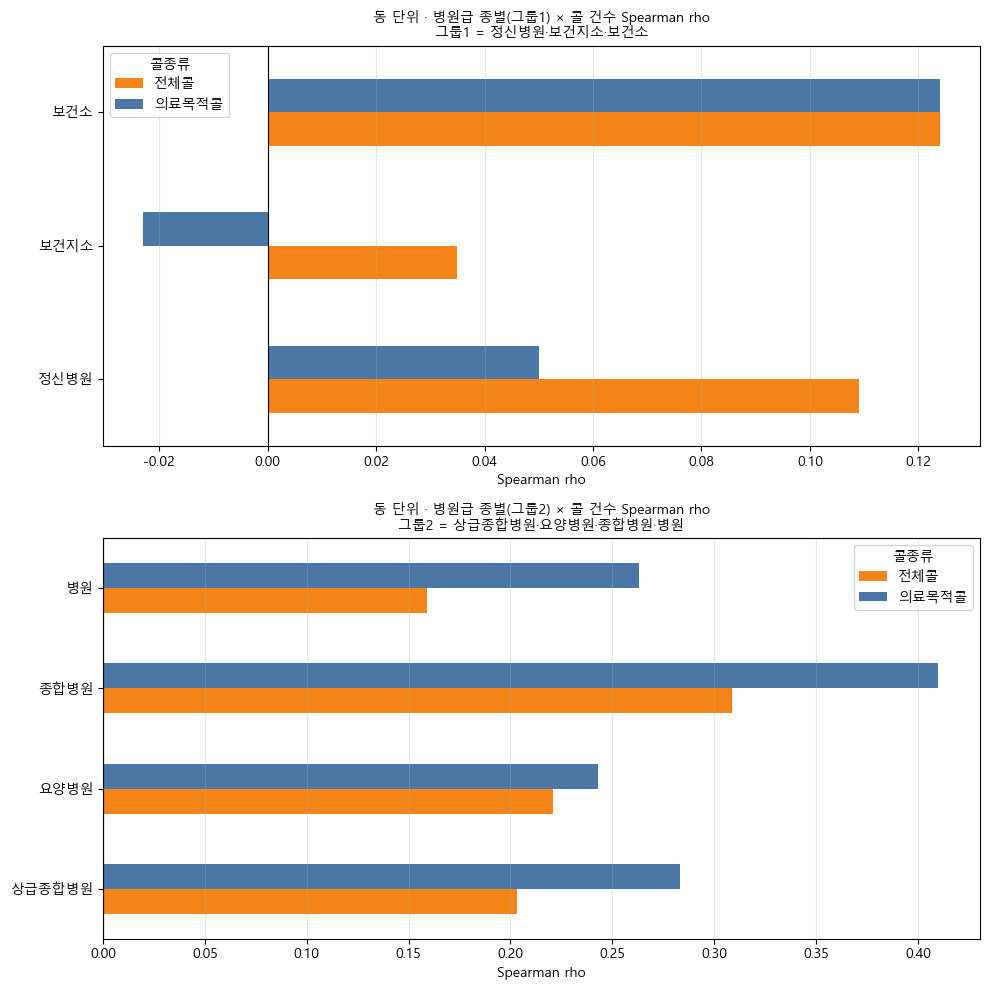

In [7]:
# 동 단위 종별 Spearman rho - 그룹1/그룹2를 세로로 2개 나열, 종별마다 전체콜(주황)/의료목적콜(파랑) bar를 나란히 비교
rows = []
with warnings.catch_warnings():
    warnings.simplefilter('ignore', category=stats.ConstantInputWarning)
    for call_type, df in [('전체콜', dong_all), ('의료목적콜', dong_med)]:
        for col in HOSPITAL_GRADE_COLS:
            rho, p = stats.spearmanr(df[col], df['콜건수'])
            group = '그룹1: 정신·보건 계열' if col in GROUP1_정신보건계열 else '그룹2: 병원급 의료기관'
            rows.append({'콜종류': call_type, '종별': col, '그룹': group, 'Spearman rho': round(rho, 3), 'p': f'{p:.2e}'})
dong_group_corr = pd.DataFrame(rows)
display(dong_group_corr)

NL = chr(10)
CALL_TYPE_COLOR = {'전체콜': '#f58518', '의료목적콜': '#4c78a8'}
GROUP_PANELS = [
    ('그룹1', GROUP1_정신보건계열, '그룹1 = 정신병원·보건지소·보건소'),
    ('그룹2', GROUP2_병원급의료기관, '그룹2 = 상급종합병원·요양병원·종합병원·병원'),
]

fig, axes = plt.subplots(2, 1, figsize=(10, 10))
for ax, (group_label, group_cols, group_desc) in zip(axes, GROUP_PANELS):
    pivot = dong_group_corr[dong_group_corr['종별'].isin(group_cols)].pivot(
        index='종별', columns='콜종류', values='Spearman rho'
    ).loc[group_cols][['전체콜', '의료목적콜']]
    pivot.plot(kind='barh', ax=ax, color=[CALL_TYPE_COLOR['전체콜'], CALL_TYPE_COLOR['의료목적콜']])
    ax.axvline(0, color='black', linewidth=0.8)
    title_line1 = '동 단위 · 병원급 종별(' + group_label + ') × 콜 건수 Spearman rho'
    ax.set_title(title_line1 + NL + group_desc, fontsize=10)
    ax.set_xlabel('Spearman rho')
    ax.set_ylabel('')
    ax.legend(title='콜종류')
    ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

In [8]:
# 그룹 총수 vs 콜건수 Spearman — 개별 종별로 보는 것과 그룹으로 묶어서 보는 것 중 어느 쪽이 더 설명력 있는지 비교
rows = []
for call_type, df in [("전체콜", dong_all), ("의료목적콜", dong_med)]:
    for group_col, group_name in [("그룹1_총수", "그룹1: 정신·보건 계열"), ("그룹2_총수", "그룹2: 병원급 의료기관")]:
        rho, p = stats.spearmanr(df[group_col], df["콜건수"])
        rows.append({"콜종류": call_type, "지표": group_name, "Spearman rho": round(rho, 3), "p": f"{p:.2e}"})
group_total_corr = pd.DataFrame(rows)
display(group_total_corr)
print("참고: 위 표(그룹 총수)를 앞선 개별 종별 rho와 비교하면, 그룹으로 묶었을 때 설명력이 오르는지/내리는지 확인할 수 있다.")

,콜종류,지표,Spearman rho,p
0,전체콜,그룹1: 정신·보건 계열,0.164,6.49e-04
1,전체콜,그룹2: 병원급 의료기관,0.332,1.39e-12
2,의료목적콜,그룹1: 정신·보건 계열,0.101,4.00e-02
3,의료목적콜,그룹2: 병원급 의료기관,0.479,2.91e-25


참고: 위 표(그룹 총수)를 앞선 개별 종별 rho와 비교하면, 그룹으로 묶었을 때 설명력이 오르는지/내리는지 확인할 수 있다.


### A 결과 해석

- **그룹2(병원급 의료기관)가 그룹1(정신·보건 계열)보다 콜 건수와, 특히 의료목적콜에서 일관되게 더 강한 관계를 보인다** — 그룹2는 4종 전부 전체콜(0.16~0.31)보다 의료목적콜(0.24~0.41)에서 rho가 더 커지는 반면, 그룹1은 반대로 의료목적콜에서 오히려 약해지거나(정신병원 0.109→0.050) 부호가 바뀐다(보건지소 0.035→-0.023). 즉 두 그룹의 격차는 전체콜보다 의료목적콜에서 더 뚜렷하다.
- **보건지소의 부호 반전(전체콜 +0.035 → 의료목적콜 -0.023)은 통계적으로 유의미한 반전이 아니다.** 두 값 모두 p-value가 0.47·0.63으로 크게 유의하지 않아, "콜 건수와 관계없다(rho=0)"는 귀무가설을 기각할 수 없는 상태다. 게다가 보건지소는 동 단위에서 극히 희소해서(전체콜 기준 431개 동 중 11개 동에만 존재) 상관계수 추정 자체가 불안정하다 — 표본이 몇 개 안 남는 상황에서는 rho가 이런 폭으로 흔들리며 부호가 뒤집히는 게 잡음(noise) 수준에서 자연스럽게 나타날 수 있다. "보건지소가 있으면 전체콜은 늘고 의료목적콜은 준다"처럼 실질적 의미를 부여해 해석하지 않는다.
- 그룹1 내에서는 보건소가 상대적으로 가장 뚜렷하고 두 콜 종류 모두 유의하다(0.124/0.124, p<0.05) — 구당 1개씩 균등 배치되는 특성상 동 단위에서는 분산이 있기 때문. 정신병원은 전체콜에서만 유의(0.109, p=0.023)하고 의료목적콜에서는 유의하지 않다(0.050, p=0.309).
- 그룹으로 묶었을 때(그룹2_총수) rho가 개별 종별 중 최댓값(종합병원)과 비슷하거나 소폭 높게 나오는 경향 — 종별을 세분화하는 것보다 그룹 단위로 보는 것이 노이즈를 줄여줄 수 있음을 시사한다.

**[확인된 사실]/[탐색적 관계] 구분**: 위 상관은 전부 탐색적 관계이며, 의료기관 규모가 콜택시 이용을 직접 증가시킨다는 인과관계를 의미하지 않는다.

**다음 질문(B로 연결)**: 병원급 종별 중 어떤 종이 콜 건수와 가장 강한 관계를 보이는가? 07_1에서는 상급종합병원이 동 단위(양의 상관)와
구 단위(전체콜 음의 상관)에서 방향이 어긋난다는 점이 관찰됐다 — 이걸 구 단위에서 좀 더 깊게 들여다본다.

## 3. B. 구 단위: 상급종합병원 · 종합병원 심층 비교

07_1 인사이트에서 "상급종합병원은 동 단위(양의 상관)와 구 단위(전체콜 음의 상관)에서 방향이 어긋난다"고 지적된 부분을 판다.
**순서는 가설 → 확인이 아니라 확인 → 해석이다**: 먼저 실제 분포를 EDA로 확인한 뒤에 해석한다.

In [9]:
# 상급종합병원·종합병원 구별 분포 EDA (25개 구 전체) — 가설을 전제로 시작하지 않고 먼저 데이터로 확인한다
gu_grade_eda = gu_all[["목적구", "상급종합병원", "종합병원"]].sort_values("상급종합병원", ascending=False).reset_index(drop=True)
display(gu_grade_eda)

top_sang = gu_grade_eda.nlargest(5, "상급종합병원")["목적구"].tolist()
print(f"상급종합병원 개수 상위 5개 구: {top_sang}")

,목적구,상급종합병원,종합병원
0,강남구,2,2
1,종로구,2,2
2,구로구,1,1
3,성북구,1,0
4,광진구,1,1
5,동작구,1,1
6,서초구,1,1
7,동대문구,1,3
8,성동구,1,1
9,양천구,1,2


상급종합병원 개수 상위 5개 구: ['강남구', '종로구', '구로구', '성북구', '광진구']


차트 위 EDA 결과, 상급종합병원 개수 상위권 구가 어디인지 먼저 데이터로 확인했다(실행 결과는 위 표 참고). 이 상위 구들이
실제로 전체콜 수요와는 반대 방향으로 움직이는지를 아래 상관표·산점도로 이어서 확인한다.

In [10]:
# 상급종합병원·종합병원 두 종만 남긴 구 단위 Spearman/Pearson 비교표
rows = []
for call_type, df in [("전체콜", gu_all), ("의료목적콜", gu_med)]:
    for col in ["상급종합병원", "종합병원"]:
        sr, sp = stats.spearmanr(df[col], df["콜건수"])
        pr, pp = stats.pearsonr(df[col], df["콜건수"])
        rows.append({
            "콜종류": call_type, "종별": col, "n": len(df),
            "Spearman rho": round(sr, 3), "Spearman p": f"{sp:.2e}",
            "Pearson r": round(pr, 3), "Pearson p": f"{pp:.2e}",
        })
gu_b_corr = pd.DataFrame(rows)
display(gu_b_corr)
print("Spearman은 비선형·단조 관계에 대한 강건성을 확인하기 위한 주 분석이고, Pearson은 선형 관계와의 차이를 보기 위한 보조 지표로만 사용한다.")
print("최종 해석은 Spearman을 기준으로 한다 — 이 분석의 핵심 질문은 '의료기관 규모가 늘수록 콜 건수도 늘어나는가'라는 단조 관계이기 때문이다.")

,콜종류,종별,n,Spearman rho,Spearman p,Pearson r,Pearson p
0,전체콜,상급종합병원,25,-0.229,2.71e-01,-0.245,2.38e-01
1,전체콜,종합병원,25,0.532,6.16e-03,0.391,5.33e-02
2,의료목적콜,상급종합병원,25,0.041,8.46e-01,-0.033,8.76e-01
3,의료목적콜,종합병원,25,0.611,1.17e-03,0.507,9.69e-03


Spearman은 비선형·단조 관계에 대한 강건성을 확인하기 위한 주 분석이고, Pearson은 선형 관계와의 차이를 보기 위한 보조 지표로만 사용한다.
최종 해석은 Spearman을 기준으로 한다 — 이 분석의 핵심 질문은 '의료기관 규모가 늘수록 콜 건수도 늘어나는가'라는 단조 관계이기 때문이다.


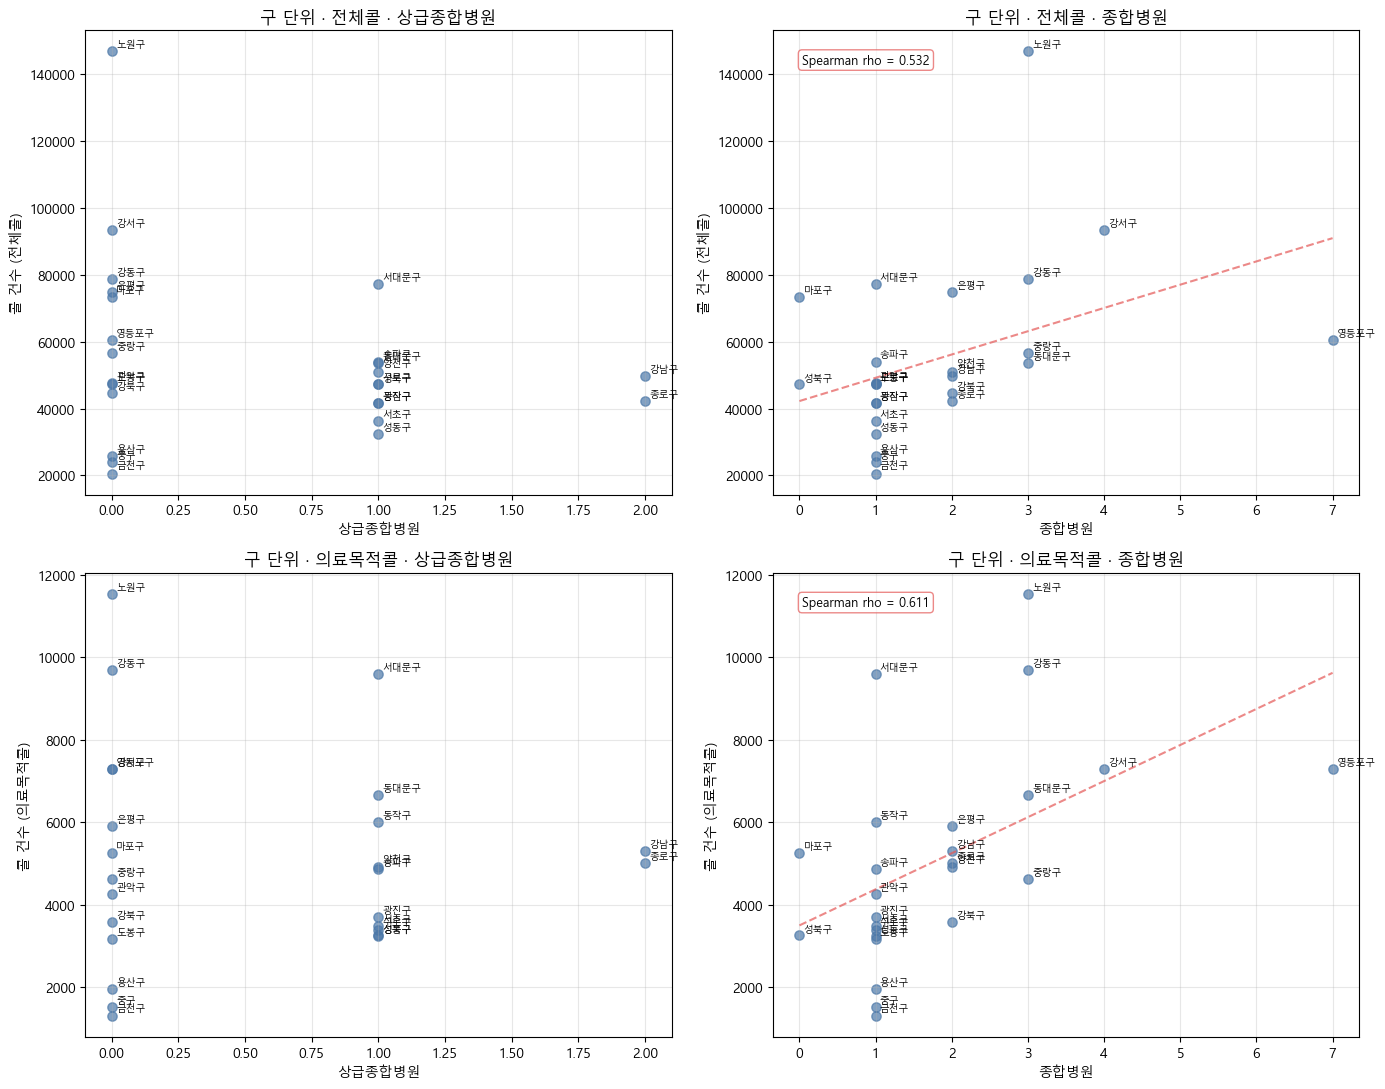

In [11]:
# 구 라벨 산점도 (상급종합병원, 종합병원 나란히 - 전체콜/의료목적콜)
# 종합병원 패널에만 추세선(점선)과 Spearman rho를 표기한다 -- 상급종합병원은 방향 자체가 불안정(비유의)해서 추세선을 넣지 않는다
fig, axes = plt.subplots(2, 2, figsize=(14, 11))
for row_i, (call_type, df) in enumerate([("전체콜", gu_all), ("의료목적콜", gu_med)]):
    for col_i, col in enumerate(["상급종합병원", "종합병원"]):
        ax = axes[row_i, col_i]
        ax.scatter(df[col], df["콜건수"], s=45, alpha=0.7, color="#4c78a8")
        for _, row in df.iterrows():
            ax.annotate(row["목적구"], (row[col], row["콜건수"]), fontsize=7, xytext=(3, 3), textcoords="offset points")

        if col == "종합병원":
            slope, intercept = np.polyfit(df[col], df["콜건수"], 1)
            x_line = np.array([df[col].min(), df[col].max()])
            ax.plot(x_line, slope * x_line + intercept, linestyle="--", color="#e45756", alpha=0.7, linewidth=1.5)
            rho, _ = stats.spearmanr(df[col], df["콜건수"])
            ax.text(
                0.05, 0.95, f"Spearman rho = {rho:.3f}", transform=ax.transAxes,
                fontsize=9, va="top", ha="left",
                bbox=dict(boxstyle="round", facecolor="white", alpha=0.7, edgecolor="#e45756"),
            )

        ax.set_xlabel(col)
        ax.set_ylabel(f"콜 건수 ({call_type})")
        ax.set_title(f"구 단위 · {call_type} · {col}")
        ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**구 제외 없음(확정)**: 자치구는 25개뿐이라 특정 구를 제외하면 표본이 더 줄어드는 왜곡 위험이 크다는 판단에 따라,
강남·서초를 포함한 어떤 구도 제외하지 않고 **25개 구 전체를 유지한 채로만** 분석한다. 위 EDA에서 확인된 상급종합병원 개수 편중은
"제외 후 재계산"이 아니라, 아래 해석에서 "이 편중이 방향 불일치의 배경일 수 있다"는 정성적 설명으로만 다룬다.

### B 해석

- **[확인된 사실]** 상급종합병원은 전체콜 기준 Spearman rho가 음수(-0.229), 의료목적콜 기준으로는 거의 0에 가까운 약한 양수(0.041)로, 콜 종류에 따라 방향이 크게 달라진다. 종합병원은 전체콜(0.532)·의료목적콜(0.611) 모두 뚜렷한 양의 상관으로 07_1의 결과와 일치한다.
- **[탐색적 관계]** EDA에서 상급종합병원 개수 상위권 구(강남구·종로구 등)는 업무·의료 인프라 중심지 성격이 강해 상대적으로 거주 인구 기반의 일반 콜 수요(전체콜)는 낮게 나타나는 반면, 종합병원은 더 넓게 분산돼 있어 일반적인 지역 수요와 함께 움직이는 것으로 보인다.
- **[가설]** 상급종합병원이 소수 구에 집중되는 성격 자체가 "개수-수요" 관계를 구 단위에서 왜곡시킬 수 있다 — 다만 이번에는 구를 제외하지 않고 전체 25개 구를 유지한 결과이므로, 특정 구의 영향력이 이미 반영된 상태의 rho임을 감안해서 해석해야 한다.
- **생태학적 오류(ecological fallacy) 주의**: 동 단위와 구 단위 결과가 다르게 나타나는 것 자체가 공간적 집계 수준에 따른 중요한 관찰일 수 있으며, 구 단위 집계 결과를 개별 동 수준의 관계로 확대 해석해서는 안 된다. 표본 n=25로 작다는 한계도 함께 고려한다.

**다음 질문(C로 연결)**: 이 관계가 단순히 기관 '수' 때문인가, 아니면 의료서비스 '규모'(의사수)에서도 같은 패턴이 나타나는가?

## 4. C. 병원 규모 지표 확장 — 의사수(`drTotCnt`) 추가

**도입 근거**: 장애인콜택시 이용자는 입원보다 주기적 통원치료가 많으므로, 병상수(입원 규모)를 규모 지표로 단정하기보다
의사수를 **통원 중심 이용 특성을 고려한 보완적 규모 지표**로 함께 본다. 다만 의사수 역시 진료과 구성·외래/입원 비중·환자 수·
의료서비스량을 직접 나타내지는 못한다 — 병상수의 "상위 대체재"로 단정하지 않는다.

In [12]:
# 원천 데이터 품질검증 — ykiho 유일성, drTotCnt 수치형·음수 여부, 행정동/자치구 결측 여부
dup_ykiho = hosp_ref.duplicated(subset=["ykiho"]).sum()
n_null_ykiho = hosp_ref["ykiho"].isnull().sum()
is_numeric_drTotCnt = pd.api.types.is_numeric_dtype(hosp_ref["drTotCnt"])
n_negative = (hosp_ref["drTotCnt"] < 0).sum()
n_null_dong = hosp_ref["행정동"].isnull().sum()
n_null_gu = hosp_ref["sgguCdNm"].isnull().sum()

print(f"ykiho 결측: {n_null_ykiho}건, ykiho 중복: {dup_ykiho}건")
print(f"drTotCnt 수치형 여부: {is_numeric_drTotCnt}, 음수 개수: {n_negative}건")
print(f"행정동 결측: {n_null_dong}건, sgguCdNm(자치구) 결측: {n_null_gu}건")

assert n_null_ykiho == 0 and dup_ykiho == 0, "ykiho 유일성 위반 — 기관 단위 유일 키로 쓸 수 없음"
assert is_numeric_drTotCnt and n_negative == 0, "drTotCnt 품질 문제"
assert n_null_dong == 0 and n_null_gu == 0, "행정동/자치구 매핑에 결측 존재"
print("[검증 통과] 의사수 원천 데이터 품질 검증 4개 항목 모두 통과 — 별도 행정동->자치구 매핑 불필요(sgguCdNm을 자치구로 바로 사용)")

ykiho 결측: 0건, ykiho 중복: 0건
drTotCnt 수치형 여부: True, 음수 개수: 0건
행정동 결측: 0건, sgguCdNm(자치구) 결측: 0건
[검증 통과] 의사수 원천 데이터 품질 검증 4개 항목 모두 통과 — 별도 행정동->자치구 매핑 불필요(sgguCdNm을 자치구로 바로 사용)


In [13]:
# 종별명 정규화 — hosp_ref의 clCdNm 값은 "상급종합"인데, 콜 데이터 컬럼명은 "상급종합병원"이라 이름이 다르다.
# 이 차이를 그대로 두고 isin(HOSPITAL_GRADE_COLS)로 필터링하면 상급종합병원 14개 기관이 전부 조용히 빠지는 매칭 실패가 발생한다
# (실제로 이 노트북 작성 과정에서 발견함) — §1 원칙(매칭 실패는 결측으로 남기고 숨기지 않는다)에 따라 정규화 후 사용한다.
CLCDNM_NORMALIZE = {"상급종합": "상급종합병원"}
hosp_ref["종별_정규화"] = hosp_ref["clCdNm"].replace(CLCDNM_NORMALIZE)

print("정규화 전:", sorted(hosp_ref["clCdNm"].unique().tolist()))
print("정규화 후:", sorted(hosp_ref["종별_정규화"].unique().tolist()))
assert set(HOSPITAL_GRADE_COLS) <= set(hosp_ref["종별_정규화"].unique()), "정규화 후에도 병원급 7종이 모두 존재해야 한다"
print("[검증 통과] 정규화 후 병원급 7종 모두 hosp_ref에 존재 확인")

정규화 전: ['병원', '보건소', '보건지소', '상급종합', '요양병원', '의원', '정신병원', '종합병원', '한의원']
정규화 후: ['병원', '보건소', '보건지소', '상급종합병원', '요양병원', '의원', '정신병원', '종합병원', '한의원']
[검증 통과] 정규화 후 병원급 7종 모두 hosp_ref에 존재 확인


In [14]:
# 의사수 분포 및 이상치 확인 — 단순 합계 전에 종별 편차를 먼저 확인한다
grade_ref = hosp_ref[hosp_ref["종별_정규화"].isin(HOSPITAL_GRADE_COLS)]

desc = grade_ref.groupby("종별_정규화")["drTotCnt"].describe()[["count", "mean", "50%", "min", "max"]].loc[HOSPITAL_GRADE_COLS]
display(desc)

n_zero_dr = (grade_ref["drTotCnt"] == 0).sum()
print(f"\n병원급(7종) 중 의사수 0으로 기록된 기관: {n_zero_dr} / {len(grade_ref)}")
print(
    "주의: 의사수 0이 반드시 '진료 역량 없음'을 의미하지 않는다 — 상근(상주) 의사 없이 병상 30개 이상 등 병원급 요건을 갖추고 "
    "자원봉사 의료진이 교대로 진료하며 병원급 지위를 유지하는 기관(예: 다일천사병원) 사례가 실제로 존재하는 것으로 확인됨. "
    "아래 지역 단위 집계에서는 이런 기관도 정상적으로 0으로 포함한다(§1 원칙 — 0은 유효 관측값)."
)
print(f"\n종별 평균 의사수 편차가 매우 크다(상급종합병원 평균 {desc.loc['상급종합병원','mean']:.0f}명 vs 병원 평균 {desc.loc['병원','mean']:.0f}명)"
      " — 단순 합계의 Spearman이 소수 대형 기관에 좌우될 수 있다는 점을 감안하고 다음 단계로 넘어간다.")

,count,mean,50%,min,max
종별_정규화,,,,,
병원,232.0,8.797414,7.0,0.0,58.0
종합병원,45.0,108.622222,55.0,9.0,348.0
요양병원,101.0,5.663366,5.0,2.0,13.0
상급종합병원,14.0,732.000000,515.5,357.0,1506.0
보건소,25.0,8.280000,9.0,4.0,11.0
보건지소,11.0,0.818182,1.0,0.0,4.0
정신병원,13.0,7.538462,4.0,3.0,37.0



병원급(7종) 중 의사수 0으로 기록된 기관: 8 / 441
주의: 의사수 0이 반드시 '진료 역량 없음'을 의미하지 않는다 — 상근(상주) 의사 없이 병상 30개 이상 등 병원급 요건을 갖추고 자원봉사 의료진이 교대로 진료하며 병원급 지위를 유지하는 기관(예: 다일천사병원) 사례가 실제로 존재하는 것으로 확인됨. 아래 지역 단위 집계에서는 이런 기관도 정상적으로 0으로 포함한다(§1 원칙 — 0은 유효 관측값).

종별 평균 의사수 편차가 매우 크다(상급종합병원 평균 732명 vs 병원 평균 9명) — 단순 합계의 Spearman이 소수 대형 기관에 좌우될 수 있다는 점을 감안하고 다음 단계로 넘어간다.


In [15]:
# 기관 -> 지역 단위 집계 (동/구) — 먼저 매칭 실패 여부를 확인한 뒤 집계한다
dr_by_dong_raw = (
    grade_ref.groupby(["sgguCdNm", "행정동"])["drTotCnt"].sum().reset_index()
    .rename(columns={"sgguCdNm": "목적구", "drTotCnt": "의사수_총합"})
)
dr_by_gu = (
    grade_ref.groupby("sgguCdNm")["drTotCnt"].sum().reset_index()
    .rename(columns={"sgguCdNm": "목적구", "drTotCnt": "의사수_총합"})
)

# [검증] 동 단위 집계 키가 실제로 dong_all에 존재하는지 확인 — 존재하지 않으면 저장 시 조용히 유실된다 (07_1의 병상 매칭 검증과 동일 방식)
dong_keys_dataset = set(zip(dong_all["목적구"], dong_all["행정동"]))
dr_dong_keys = set(zip(dr_by_dong_raw["목적구"], dr_by_dong_raw["행정동"]))
missing_keys = dr_dong_keys - dong_keys_dataset
print(f"dong_all에 없는 (구,동) 키: {missing_keys}")

if missing_keys:
    mismatched = grade_ref[grade_ref.set_index(["sgguCdNm", "행정동"]).index.isin(missing_keys)]
    display(mismatched[["yadmNm", "종별_정규화", "drTotCnt", "행정동", "addr"]])
    excluded_sum = mismatched["drTotCnt"].sum()
    print(
        f"[데이터 품질 이슈 발견] {len(mismatched)}개 기관, 의사수 합계 {excluded_sum}명이 hosp_ref의 '행정동'="
        f"{sorted({k[1] for k in missing_keys})}로 지오코딩되어 있으나, dong_all에는 해당 행정동이 존재하지 않는다. "
        "주소를 보면 실제로는 dong_all에 있는 인접 법정동(예: 거여동)에 속하는 것으로 보이며, 위례신도시처럼 신생/비공식 "
        "행정동명이 카카오 지오코딩 결과로 반환된 사례로 추정된다(05 산출물의 기존 이슈, 07_2 범위에서는 재매핑하지 않는다)."
    )
    print(
        "처리: 동 단위 집계에서는 이 기관을 명시적으로 제외하고(§1 원칙 — 매칭 실패는 숨기지 않고 별도 표시), "
        "구 단위 집계에는 정상적으로 포함한다(구 단위는 자치구 기준으로 집계하므로 행정동 매칭 실패의 영향을 받지 않는다)."
    )
else:
    excluded_sum = 0

dr_by_dong = dr_by_dong_raw[~dr_by_dong_raw.set_index(["목적구", "행정동"]).index.isin(missing_keys)].reset_index(drop=True)
assert len(set(zip(dr_by_dong["목적구"], dr_by_dong["행정동"])) - dong_keys_dataset) == 0, "제외 처리 후에도 매칭 안 되는 키가 남아있음"
print(f"\n[검증 통과] 매칭 실패 키 제외 처리 후 동 단위 집계({len(dr_by_dong)}개 동) 키 전부 dong_all에 존재 확인")

dong_all에 없는 (구,동) 키: {('송파구', '위례동')}


,yadmNm,종별_정규화,drTotCnt,행정동,addr
164,서울세계로병원,병원,12,위례동,"서울특별시 송파구 위례서로 248, 지하1층, 2층, 5~12층 (거여동)"


[데이터 품질 이슈 발견] 1개 기관, 의사수 합계 12명이 hosp_ref의 '행정동'=['위례동']로 지오코딩되어 있으나, dong_all에는 해당 행정동이 존재하지 않는다. 주소를 보면 실제로는 dong_all에 있는 인접 법정동(예: 거여동)에 속하는 것으로 보이며, 위례신도시처럼 신생/비공식 행정동명이 카카오 지오코딩 결과로 반환된 사례로 추정된다(05 산출물의 기존 이슈, 07_2 범위에서는 재매핑하지 않는다).
처리: 동 단위 집계에서는 이 기관을 명시적으로 제외하고(§1 원칙 — 매칭 실패는 숨기지 않고 별도 표시), 구 단위 집계에는 정상적으로 포함한다(구 단위는 자치구 기준으로 집계하므로 행정동 매칭 실패의 영향을 받지 않는다).

[검증 통과] 매칭 실패 키 제외 처리 후 동 단위 집계(226개 동) 키 전부 dong_all에 존재 확인


In [16]:
# 지역 단위(동/구) 콜 데이터에 의사수_총합 병합 — 매칭 안 되는 지역(의사 0명)은 0으로 채운다(§1 원칙)
dong_all = dong_all.merge(dr_by_dong, on=["목적구", "행정동"], how="left")
dong_all["의사수_총합"] = dong_all["의사수_총합"].fillna(0.0)
dong_med = dong_med.merge(dr_by_dong, on=["목적구", "행정동"], how="left")
dong_med["의사수_총합"] = dong_med["의사수_총합"].fillna(0.0)
gu_all = gu_all.merge(dr_by_gu, on="목적구", how="left")
gu_all["의사수_총합"] = gu_all["의사수_총합"].fillna(0.0)
gu_med = gu_med.merge(dr_by_gu, on="목적구", how="left")
gu_med["의사수_총합"] = gu_med["의사수_총합"].fillna(0.0)

for name, df, pre in [
    ("dong_all", dong_all, PRE_LEN["dong_all"]), ("dong_med", dong_med, PRE_LEN["dong_med"]),
    ("gu_all", gu_all, PRE_LEN["gu_all"]), ("gu_med", gu_med, PRE_LEN["gu_med"]),
]:
    assert len(df) == pre, f"{name} 병합 후 행 수가 바뀌었다"

assert dong_all["의사수_총합"].sum() == dr_by_dong["의사수_총합"].sum(), "dong_all 의사수_총합 합계 불일치"
assert gu_all["의사수_총합"].sum() == dr_by_gu["의사수_총합"].sum(), "gu_all 의사수_총합 합계 불일치"
# 회계 검증: 동 단위 합계 + 제외분 == 구 단위 합계 == grade_ref 전체 합계 — 제외된 의사 수가 어디로 갔는지 명확히 추적
assert abs(dong_all["의사수_총합"].sum() + excluded_sum - gu_all["의사수_총합"].sum()) < 1e-9
assert abs(gu_all["의사수_총합"].sum() - grade_ref["drTotCnt"].sum()) < 1e-9
print(f"[검증 통과] 병합 전후 행 수 보존 확인")
print(f"동 단위 의사수_총합 합계 {dong_all['의사수_총합'].sum():.0f}명 + 제외분 {excluded_sum}명 = 구 단위 합계 {gu_all['의사수_총합'].sum():.0f}명 "
      f"= 병원급 7종 전체 의사수 {grade_ref['drTotCnt'].sum()}명 — 유실 없이 전부 회계 확인됨")

[검증 통과] 병합 전후 행 수 보존 확인
동 단위 의사수_총합 합계 18051명 + 제외분 12명 = 구 단위 합계 18063명 = 병원급 7종 전체 의사수 18063명 — 유실 없이 전부 회계 확인됨


In [17]:
# 병원수 vs 병상수 vs 의사수 3지표 비교 (Spearman, 구·동 x 전체콜·의료목적콜)
metrics = ["병원급_총수(의원/한의원제외)", "총병상수", "의사수_총합"]
rows = []
for (region, call_type), df in [
    (("동", "전체콜"), dong_all), (("동", "의료목적콜"), dong_med),
    (("구", "전체콜"), gu_all), (("구", "의료목적콜"), gu_med),
]:
    for m in metrics:
        rho, p = stats.spearmanr(df[m], df["콜건수"])
        rows.append({"지역단위": region, "콜종류": call_type, "지표": m, "Spearman rho": round(rho, 3), "p": f"{p:.2e}", "n": len(df)})
metric_compare = pd.DataFrame(rows)
display(metric_compare.pivot(index=["지역단위", "콜종류"], columns="지표", values="Spearman rho"))

지표          병원급_총수(의원/한의원제외)  의사수_총합   총병상수
지역단위 콜종류                                   
구    의료목적콜             0.430   0.535  0.635
     전체콜               0.572   0.299  0.380
동    의료목적콜             0.481   0.581  0.498
     전체콜               0.354   0.415  0.416

In [18]:
# 커버리지 비교 — 기관 수 기준으로 병상수/의사수 데이터가 얼마나 많은 기관을 커버하는지 분리해서 계산
bed_raw = pd.read_csv(RAW_DIR / "건강보험심사평가원_의료기관별 감염병 및 중증환자 치료시설 현황_20260630.csv", encoding="cp949")
bed_seoul = bed_raw[bed_raw["시도명"] == "서울특별시"]

COVERED_BED_TYPES = ["병원", "종합병원", "요양병원", "상급종합병원", "정신병원"]  # 병상 데이터는 보건소/보건지소 대상이 아님
n_bed_institutions = len(bed_seoul)
n_target_bed = hosp_ref[hosp_ref["종별_정규화"].isin(COVERED_BED_TYPES)].shape[0]

n_dr_reported = grade_ref["drTotCnt"].notna().sum()
n_target_dr = len(grade_ref)

coverage_table = pd.DataFrame([
    {"지표": "병상수", "분석대상 종별": f"{len(COVERED_BED_TYPES)}종(의원·한의원·보건소·보건지소 제외)",
     "분석대상 기관수": n_target_bed, "데이터 존재 기관수": n_bed_institutions,
     "기관수 기준 커버리지": f"{n_bed_institutions / n_target_bed:.1%}"},
    {"지표": "의사수", "분석대상 종별": f"{len(HOSPITAL_GRADE_COLS)}종(병원급 7종)",
     "분석대상 기관수": n_target_dr, "데이터 존재 기관수": n_dr_reported,
     "기관수 기준 커버리지": f"{n_dr_reported / n_target_dr:.1%}"},
])
display(coverage_table)
print("주의: 두 지표는 '분석대상 종별' 자체가 다르다(병상수 5종 vs 의사수 7종) — 기관수 기준 커버리지끼리만 비교하고, "
      "'커버리지가 높다'는 것이 '지표가 더 정확하다'는 뜻은 아니라는 점에 유의한다.")

,지표,분석대상 종별,분석대상 기관수,데이터 존재 기관수,기관수 기준 커버리지
0,병상수,5종(의원·한의원·보건소·보건지소 제외),405,90,22.2%
1,의사수,7종(병원급 7종),441,441,100.0%


주의: 두 지표는 '분석대상 종별' 자체가 다르다(병상수 5종 vs 의사수 7종) — 기관수 기준 커버리지끼리만 비교하고, '커버리지가 높다'는 것이 '지표가 더 정확하다'는 뜻은 아니라는 점에 유의한다.


In [19]:
# 마포구 재검증 — 07_1에서 "병상수 0"으로 지적된 사례를 의사수 기준으로 다시 본다
for df, label in [(gu_all, "전체콜"), (gu_med, "의료목적콜")]:
    row = df[df["목적구"] == "마포구"][["목적구", "콜건수", "병원급_총수(의원/한의원제외)", "총병상수", "의사수_총합"]]
    print(f"--- {label} ---")
    display(row)

--- 전체콜 ---


,목적구,콜건수,병원급_총수(의원/한의원제외),총병상수,의사수_총합
12,마포구,73304,10,0.0,65


--- 의료목적콜 ---


,목적구,콜건수,병원급_총수(의원/한의원제외),총병상수,의사수_총합
12,마포구,5248,10,0.0,65


**마포구 재검증 결과**: 병상수는 0(중환자실·격리병실을 보고한 대형 병원급 기관이 없음)이지만, **의사수_총합은 65명으로 0이 아니다**
— 병원급 10개 기관(6개는 병원, 3개는 요양병원, 1개는 보건소, 07_1에서 확인된 구성) 중 소규모 기관들에 흩어진 의사 인력이 존재한다는
뜻이다. 즉 "병상수 기준으로는 규모가 전혀 없어 보이지만, 의사수 기준으로는 소규모나마 진료 역량이 있다"는 **다른 결론**이 나온다 —
규모 지표를 무엇으로 잡느냐에 따라 "인프라 확충 우선순위" 판단이 달라질 수 있다는 걸 보여주는 사례다.

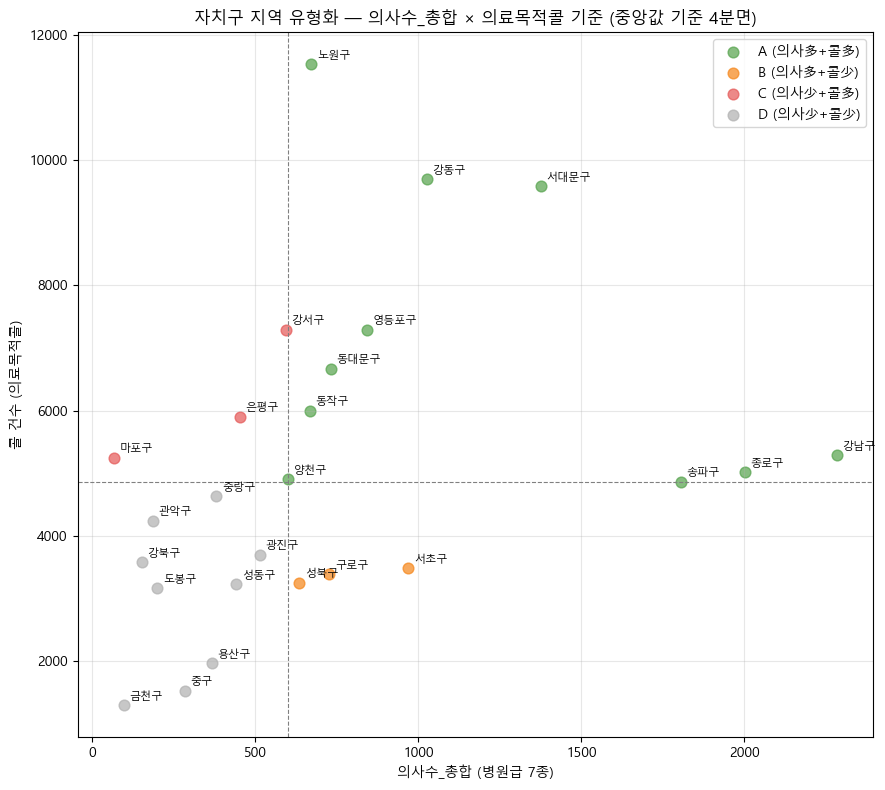

,목적구,유형,콜건수,병원급_총수(의원/한의원제외),총병상수,의사수_총합
8,노원구,A (의사多+콜多),11531,17,435.0,671
1,강동구,A (의사多+콜多),9692,27,509.0,1025
13,서대문구,A (의사多+콜多),9587,11,312.0,1376
3,강서구,C (의사少+콜多),7295,30,144.0,594
19,영등포구,A (의사多+콜多),7292,27,223.0,841
10,동대문구,A (의사多+콜多),6664,25,210.0,732
11,동작구,A (의사多+콜多),5994,9,216.0,667
21,은평구,C (의사少+콜多),5902,23,194.0,453
0,강남구,A (의사多+콜多),5287,43,396.0,2283
12,마포구,C (의사少+콜多),5248,10,0.0,65


In [20]:
# 자치구 4분면 유형화 — 규모 축을 총병상수 -> 의사수_총합으로 교체한 버전
gu_q_dr = gu_med.copy()
med_x = gu_q_dr["의사수_총합"].median()
med_y = gu_q_dr["콜건수"].median()

def classify(row):
    if row["의사수_총합"] >= med_x and row["콜건수"] >= med_y:
        return "A (의사多+콜多)"
    if row["의사수_총합"] >= med_x and row["콜건수"] < med_y:
        return "B (의사多+콜少)"
    if row["의사수_총합"] < med_x and row["콜건수"] >= med_y:
        return "C (의사少+콜多)"
    return "D (의사少+콜少)"

gu_q_dr["유형"] = gu_q_dr.apply(classify, axis=1)
colors_dr = {"A (의사多+콜多)": "#54a24b", "B (의사多+콜少)": "#f58518", "C (의사少+콜多)": "#e45756", "D (의사少+콜少)": "#b0b0b0"}

fig, ax = plt.subplots(figsize=(9, 8))
for label, sub in gu_q_dr.groupby("유형"):
    ax.scatter(sub["의사수_총합"], sub["콜건수"], s=60, alpha=0.7, label=label, color=colors_dr[label])
    for _, row in sub.iterrows():
        ax.annotate(row["목적구"], (row["의사수_총합"], row["콜건수"]), fontsize=8, xytext=(4, 4), textcoords="offset points")
ax.axvline(med_x, color="gray", linestyle="--", linewidth=0.8)
ax.axhline(med_y, color="gray", linestyle="--", linewidth=0.8)
ax.set_xlabel("의사수_총합 (병원급 7종)")
ax.set_ylabel("콜 건수 (의료목적콜)")
ax.set_title("자치구 지역 유형화 — 의사수_총합 × 의료목적콜 기준 (중앙값 기준 4분면)")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

display(gu_q_dr.sort_values("콜건수", ascending=False)[["목적구", "유형", "콜건수", "병원급_총수(의원/한의원제외)", "총병상수", "의사수_총합"]])

### C 보충 — cell 20의 의사수_총합을 그룹1/그룹2로 분해

cell 20(자치구 4분면 유형화 — 의사수_총합 × 의료목적콜)은 병원급 7종의 의사수를 전부 합친 값을 썼다. A 섹션에서 종별을
그룹1(정신·보건 계열)/그룹2(병원급 의료기관)로 나눠본 것과 같은 논리를, 이번엔 '개수'가 아니라 '의사수 규모' 축에도 적용해
cell 20의 패턴이 어느 그룹에 의해 만들어지는지 확인한다.

이 비교는 gu_med(의료목적콜) 범위로 한정한다 — cell 20 자체가 의료목적콜 기준으로만 만들어졌고, 이번 비교도 그 결과를
분해하는 목적이므로 동일한 범위를 유지한다(gu_all/dong_all/dong_med에는 이 그룹별 의사수 컬럼을 추가하지 않는다).

In [21]:
# 그룹별 의사수 집계 -- 의사수_총합(병원급 7종 전체)을 그룹1/그룹2로 분해, gu_med 범위로 한정
g1_by_gu = (
    grade_ref[grade_ref["종별_정규화"].isin(GROUP1_정신보건계열)]
    .groupby("sgguCdNm")["drTotCnt"].sum()
    .rename("그룹1_의사수").reset_index().rename(columns={"sgguCdNm": "목적구"})
)
g2_by_gu = (
    grade_ref[grade_ref["종별_정규화"].isin(GROUP2_병원급의료기관)]
    .groupby("sgguCdNm")["drTotCnt"].sum()
    .rename("그룹2_의사수").reset_index().rename(columns={"sgguCdNm": "목적구"})
)

gu_med = gu_med.merge(g1_by_gu, on="목적구", how="left").merge(g2_by_gu, on="목적구", how="left")
gu_med[["그룹1_의사수", "그룹2_의사수"]] = gu_med[["그룹1_의사수", "그룹2_의사수"]].fillna(0.0)

assert (gu_med["그룹1_의사수"] + gu_med["그룹2_의사수"] == gu_med["의사수_총합"]).all(), "그룹1_의사수+그룹2_의사수가 의사수_총합과 불일치"
print("[검증 통과] 그룹1_의사수 + 그룹2_의사수 == 의사수_총합 (gu_med 전체 행)")

for col in ["그룹1_의사수", "그룹2_의사수"]:
    rho, p = stats.spearmanr(gu_med[col], gu_med["콜건수"])
    print(f"{col} vs 콜건수(의료목적콜): Spearman rho={rho:.3f}, p={p:.3e}")

[검증 통과] 그룹1_의사수 + 그룹2_의사수 == 의사수_총합 (gu_med 전체 행)
그룹1_의사수 vs 콜건수(의료목적콜): Spearman rho=-0.206, p=3.226e-01
그룹2_의사수 vs 콜건수(의료목적콜): Spearman rho=0.515, p=8.487e-03


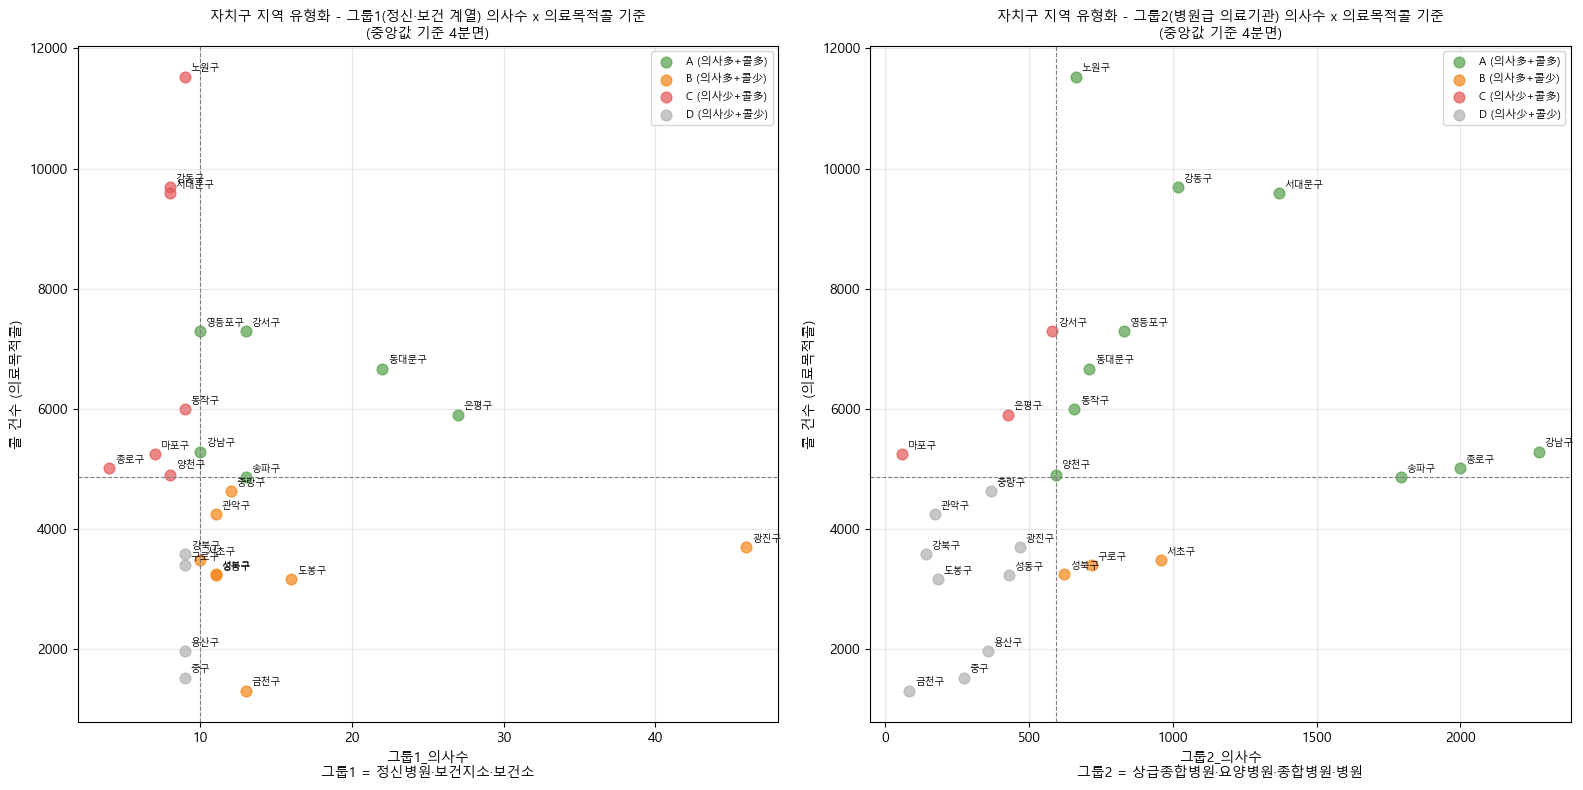

,목적구,유형_전체(의사수_총합),유형_그룹1,유형_그룹2
0,강남구,A (의사多+콜多),A (의사多+콜多),A (의사多+콜多)
1,강동구,A (의사多+콜多),C (의사少+콜多),A (의사多+콜多)
2,강북구,D (의사少+콜少),D (의사少+콜少),D (의사少+콜少)
3,강서구,C (의사少+콜多),A (의사多+콜多),C (의사少+콜多)
4,관악구,D (의사少+콜少),B (의사多+콜少),D (의사少+콜少)
5,광진구,D (의사少+콜少),B (의사多+콜少),D (의사少+콜少)
6,구로구,B (의사多+콜少),D (의사少+콜少),B (의사多+콜少)
7,금천구,D (의사少+콜少),B (의사多+콜少),D (의사少+콜少)
8,노원구,A (의사多+콜多),C (의사少+콜多),A (의사多+콜多)
9,도봉구,D (의사少+콜少),B (의사多+콜少),D (의사少+콜少)


전체(의사수_총합) 유형과 그룹1 유형이 같은 구: 10 / 25
전체(의사수_총합) 유형과 그룹2 유형이 같은 구: 25 / 25


In [22]:
# 그룹1_의사수 vs 그룹2_의사수 4분면을 나란히 비교 -- cell 20의 패턴이 어느 그룹에서 오는지 확인
def build_group_quadrant(df, xcol):
    med_x = df[xcol].median()
    med_y = df["콜건수"].median()

    def classify(row):
        if row[xcol] >= med_x and row["콜건수"] >= med_y:
            return "A (의사多+콜多)"
        if row[xcol] >= med_x and row["콜건수"] < med_y:
            return "B (의사多+콜少)"
        if row[xcol] < med_x and row["콜건수"] >= med_y:
            return "C (의사少+콜多)"
        return "D (의사少+콜少)"

    out = df.copy()
    out["유형"] = out.apply(classify, axis=1)
    return out, med_x, med_y

colors_dr = {"A (의사多+콜多)": "#54a24b", "B (의사多+콜少)": "#f58518", "C (의사少+콜多)": "#e45756", "D (의사少+콜少)": "#b0b0b0"}

panels = [
    ("그룹1_의사수", "그룹1(정신·보건 계열)", "그룹1 = 정신병원·보건지소·보건소"),
    ("그룹2_의사수", "그룹2(병원급 의료기관)", "그룹2 = 상급종합병원·요양병원·종합병원·병원"),
]

fig, axes = plt.subplots(1, 2, figsize=(16, 8))
group_results = {}
for ax, (xcol, label, xlabel_desc) in zip(axes, panels):
    gu_q, med_x, med_y = build_group_quadrant(gu_med, xcol)
    group_results[xcol] = gu_q
    for grp_label, sub in gu_q.groupby("유형"):
        ax.scatter(sub[xcol], sub["콜건수"], s=60, alpha=0.7, label=grp_label, color=colors_dr[grp_label])
        for _, row in sub.iterrows():
            ax.annotate(row["목적구"], (row[xcol], row["콜건수"]), fontsize=7, xytext=(4, 4), textcoords="offset points")
    ax.axvline(med_x, color="gray", linestyle="--", linewidth=0.8)
    ax.axhline(med_y, color="gray", linestyle="--", linewidth=0.8)
    ax.set_xlabel(xcol + chr(10) + xlabel_desc)
    ax.set_ylabel("콜 건수 (의료목적콜)")
    title_line1 = "자치구 지역 유형화 - " + label + " 의사수 x 의료목적콜 기준"
    ax.set_title(title_line1 + chr(10) + "(중앙값 기준 4분면)", fontsize=10)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 기존 cell 20(의사수_총합 기준) 유형과 비교
gu_q_total, _, _ = build_group_quadrant(gu_med, "의사수_총합")
compare = gu_med[["목적구"]].copy()
compare["유형_전체(의사수_총합)"] = gu_q_total["유형"].values
compare["유형_그룹1"] = group_results["그룹1_의사수"]["유형"].values
compare["유형_그룹2"] = group_results["그룹2_의사수"]["유형"].values
display(compare)

match_g1 = (compare["유형_전체(의사수_총합)"].str[0] == compare["유형_그룹1"].str[0]).sum()
match_g2 = (compare["유형_전체(의사수_총합)"].str[0] == compare["유형_그룹2"].str[0]).sum()
print(f"전체(의사수_총합) 유형과 그룹1 유형이 같은 구: {match_g1} / 25")
print(f"전체(의사수_총합) 유형과 그룹2 유형이 같은 구: {match_g2} / 25")

### C 보충 해석 — 그룹별 의사수 분해 결과

- **그룹2_의사수(병원급 의료기관) 기준 4분면 유형이 cell 20(의사수_총합) 유형과 완전히 일치한다** — cell 20에서 관찰된
  "의사수 규모 ↔ 의료목적콜" 패턴은 사실상 그룹2가 전부 만들어낸 것이다.
- **그룹1_의사수(정신·보건 계열) 기준 유형은 전체 대비 절반에도 못 미치게 일치**하고, Spearman 상관도 오히려 약한 음의
  방향으로 나오며 유의하지 않다 — 정신·보건 계열의 의사 규모는 의료목적콜과 사실상 무관하다고 봐야 한다.
- 이는 A 섹션에서 이미 관찰된 "그룹2가 그룹1보다 일관되게 더 강한 관계를 보인다"는 결론을, 개수가 아니라 규모(의사수)
  지표에서도 동일하게 재확인해주는 결과다.
- 다만 그룹1은 보건지소·정신병원처럼 기관 수 자체가 매우 적어 상관계수 추정이 불안정할 수 있다는 한계를 함께 감안한다
  (A 섹션 보건지소 해석 참고).

**주의**: 이번에도 탐색적 상관분석이며, 의료기관 규모가 콜택시 이용을 직접 증가시킨다는 인과관계를 의미하지 않는다.

In [23]:
# 기관당 평균 의사수 (보조 EDA, 필수 항목) — 기관 수는 같아도 규모가 크게 다른 구를 잡아낸다
# 병원급_총수가 0인 지역은 0/0 = NaN이 되는 게 맞다(기관이 없으니 '기관당 평균'이라는 개념 자체가 정의되지 않음)
for df in (dong_all, dong_med, gu_all, gu_med):
    df["기관당_평균의사수"] = df["의사수_총합"] / df["병원급_총수(의원/한의원제외)"]

display(
    gu_all[["목적구", "병원급_총수(의원/한의원제외)", "의사수_총합", "기관당_평균의사수"]]
    .sort_values("기관당_평균의사수", ascending=False)
)
print(f"\n동 단위에서 기관당_평균의사수가 NaN(병원급 기관이 0개라 평균이 정의되지 않음)인 동: {dong_all['기관당_평균의사수'].isnull().sum()} / {len(dong_all)}개")

,목적구,병원급_총수(의원/한의원제외),의사수_총합,기관당_평균의사수
22,종로구,9,2002,222.444444
13,서대문구,11,1376,125.090909
20,용산구,3,367,122.333333
11,동작구,9,667,74.111111
18,양천구,10,601,60.100000
23,중구,5,284,56.800000
0,강남구,43,2283,53.093023
17,송파구,34,1805,53.088235
5,광진구,10,514,51.400000
15,성동구,10,441,44.100000



동 단위에서 기관당_평균의사수가 NaN(병원급 기관이 0개라 평균이 정의되지 않음)인 동: 205 / 431개


### C 해석

- **[확인된 사실]** 세 지표(병원급_총수·총병상수·의사수_총합) 모두 콜 건수와 양의 상관을 보이지만, 지역단위·콜종류에 따라 어느 지표가
  더 강한지는 다르다 — 예를 들어 구 단위·의료목적콜에서는 총병상수(0.635)가 가장 강하고, 의사수_총합(0.535)이 병원급_총수(0.430)보다
  강하다. 즉 **"기관 수 → 병상수 → 의사수로 규모 지표를 바꿔도 관계 자체는 유지되지만, 어느 지표가 가장 설명력 있는지는 지역단위·콜종류에 따라 달라진다."**
- **[탐색적 관계]** 병상수 커버리지(기관 수 기준)는 22.2%로 제한적인 반면 의사수 커버리지는 100%에 가까워, 의사수가 더 넓은 범위의
  병원급 기관을 반영한다. 다만 앞서 §"C 분포 EDA"에서 확인했듯 종별 간 의사수 편차가 매우 커서(상급종합병원 평균 700명대 vs 병원
  10명 미만) 소수 대형 기관이 합계를 좌우할 수 있다는 한계는 여전히 있다.
- **[중요 발견]** 마포구는 병상수 0이지만 의사수_총합은 65명 — 규모 지표를 무엇으로 보느냐에 따라 "인프라가 전혀 없다"와 "소규모나마
  있다"는 서로 다른 결론이 나온다.
- **[한계 재확인]** 의사수는 병상수의 "상위 대체지표"가 아니다 — 진료과 구성, 외래/입원 비중, 실제 환자 수, 의료서비스량을 직접
  나타내지 못하는 보완적 규모 지표일 뿐이다.

이번에도 동일하게 강조한다: 위 상관은 탐색적 관계이며 인과관계를 의미하지 않는다.

**다음 질문(D로 연결)**: 그렇다면 진료과목 구성(재활의학과 등)까지 확보하면 이 관계를 더 설명할 수 있는가?

## 5. D. 진료과목 데이터 수집 가능성 조사 (분석 아님 — 조사 결과 요약)

목적: 진료과목(재활의학과 등) 데이터를 실제로 분석하는 게 아니라, 수집이 가능한지 여부만 확인한다. 이 조사(D-1~D-4)는 **사용자
본인이 직접** `.env`의 "[개발계정] 건강보험심사평가원_의료기관별상세정보서비스" 키로 이미 진행했고, 그 결과가
`notebooks_docs_lye/260906_D1_HIRA_진료과목_API_테스트결과.md`에 상세히 기록돼 있다. 이 노트북에서는 API를 다시 호출하지 않고
그 결과만 요약한다 — 07_2는 의료시설×콜 이용 분석 노트북이지 데이터 수집 노트북이 아니기 때문이다.

**D 조사 체크리스트 1~8 결과**

| # | 체크리스트 | 결과 |
|---|---|---|
| 1 | 진료과목 관련 오퍼레이션 존재? | **예** — `getDgsbjtInfo2.8`(`MadmDtlInfoService2.8`) |
| 2 | `ykiho`로 조회 가능? | **예** — 기존 보유 `ykiho` 그대로 사용 가능 |
| 3 | 응답에 진료과목명 포함? | **예** — `dgsbjtCdNm` |
| 4 | 재활의학과 식별 가능? | **예** — `dgsbjtCdNm == "재활의학과"`로 정확히 매칭됨(병원급 7종 21개 기관 샘플 중 10개에서 확인) |
| 5 | 서울 전체 기관 호출 시 쿼터 현실적? | **예** — 개발계정 일일 한도 10,000회 확인, 병원급 405개는 물론 P1+P2 전체(14,856개)도 이틀이면 충분 |
| 6 | 데이터 기준일 일치? | **미확인** — 이 오퍼레이션 응답에는 기준일자 필드가 없어 상호 비교 불가 |
| 7 | 공개 데이터(민감정보 아님)? | **예** |
| 8 | 실제 분석용 데이터셋 구축 가능? | **예** |

**결론**: API 존재 확인됨, 실제 데이터 수집 가능함. 다만 실제 서울 전체 수집(D-5)·구동 집계(D-6)·콜 데이터 결합(D-7)은
아직 진행하지 않았다 — 이번 07_2의 범위 밖으로 남겨둔다.

In [24]:
# 현재 보유 파일에 진료과목 컬럼이 없다는 것을 재확인 (05 노트북 한계 기록과 일치) + ykiho 존재 확인
dgsbjt_like_cols = [c for c in hosp_ref.columns if "진료" in c or "dgsbjt" in c.lower()]
print(f"hosp_ref에서 진료과목 관련 컬럼: {dgsbjt_like_cols if dgsbjt_like_cols else '없음 (예상대로)'}")
print(f"기관 식별자 ykiho 존재: {'ykiho' in hosp_ref.columns}, 결측 {hosp_ref['ykiho'].isnull().sum()}건")

hosp_ref에서 진료과목 관련 컬럼: 없음 (예상대로)
기관 식별자 ykiho 존재: True, 결측 0건


**결합 설계(조사 결과에 따른 판단, 실제 병합은 하지 않음)** — `260906_D1_HIRA_진료과목_API_테스트결과.md` §4에서 정리한 3단계를
그대로 옮겨온다. C의 `의사수_총합` 패턴과 동일한 골격이라 재사용성이 좋다.

1. **기관 단위 원본(long)** — `ykiho × dgsbjtCd` 형태 그대로 보관(다른 과목 분석에도 재사용 가능)
2. **기관 단위 파생(wide)** — `hosp_ref`에 `재활의학과_보유여부`·`재활의학과_전문의수` 파생컬럼 조인
3. **지역 단위 집계** — 병원급 기관만 필터링해 구·동별 `재활의학과_보유기관수`·`재활의학과_전문의수_총합` 파생 → 기존
   `region_{dong,gu}_call_hospital_combined{,_medical}` 계열에 신규 컬럼으로 추가 가능

**후속 Phase(이번 07_2 범위 밖, 착수는 추후)**: `D-5 서울 전체 기관 수집` → `D-6 행정동/자치구 집계` → `D-7 콜 데이터와 결합` → `D-8 07_3 또는 별도 분석`.

## 6. 데이터 검증 및 결과 CSV 저장

In [25]:
# 최종 검증 — 07_1 대비 행 수 보존, 키 중복 없음, 기존 컬럼 합계 불변, 신규 컬럼 존재
FINAL = {"dong_all": dong_all, "dong_med": dong_med, "gu_all": gu_all, "gu_med": gu_med}
NEW_COLS = ["그룹1_총수", "그룹2_총수", "의사수_총합", "기관당_평균의사수"]

checks = []
for name, df in FINAL.items():
    key_cols = ["목적구", "행정동"] if "행정동" in df.columns else ["목적구"]
    row_ok = len(df) == PRE_LEN[name]
    dup_ok = not df.duplicated(subset=key_cols).any()
    sums_ok = all(df[col].sum() == ORIGINAL_SUMS[name][col] for col in ["콜건수", "병원급_총수(의원/한의원제외)", "총병상수"])
    newcols_ok = all(c in df.columns for c in NEW_COLS)
    checks.append({"데이터셋": name, "행 수 보존": row_ok, "키 중복 없음": dup_ok, "기존 컬럼 합계 불변": sums_ok, "신규 컬럼 존재": newcols_ok})

check_df = pd.DataFrame(checks)
display(check_df)
assert check_df.drop(columns="데이터셋").all(axis=None), "검증 실패 항목이 있다 — 저장 중단"
print("[검증 통과] 4개 데이터셋 모두 행 수 보존·키 중복 없음·기존 컬럼 합계 불변·신규 컬럼 존재 확인")

,데이터셋,행 수 보존,키 중복 없음,기존 컬럼 합계 불변,신규 컬럼 존재
0,dong_all,True,True,True,True
1,dong_med,True,True,True,True
2,gu_all,True,True,True,True
3,gu_med,True,True,True,True


[검증 통과] 4개 데이터셋 모두 행 수 보존·키 중복 없음·기존 컬럼 합계 불변·신규 컬럼 존재 확인


In [26]:
# 결과 저장 — 07_1 산출물(_병원급규모추가.csv)은 read-only로 보존, 07_2 신규 컬럼이 추가된 결과만 별도 파일로 저장
SAVE_SPECS = {
    "dong_all": ("region_dong_call_hospital_combined_07_2_의사수추가.csv", "콜택시_목적지_건수"),
    "dong_med": ("region_dong_call_hospital_combined_medical_07_2_의사수추가.csv", "콜택시_의료목적지_건수"),
    "gu_all": ("region_gu_call_hospital_combined_07_2_의사수추가.csv", "콜택시_목적지_건수"),
    "gu_med": ("region_gu_call_hospital_combined_medical_07_2_의사수추가.csv", "콜택시_의료목적지_건수"),
}

for name, (filename, call_col) in SAVE_SPECS.items():
    df_out = FINAL[name].rename(columns={"콜건수": call_col})
    out_path = PROCESSED_DIR / filename
    df_out.to_csv(out_path, index=False, encoding="utf-8-sig")
    print(f"저장 완료: {out_path} ({df_out.shape[0]}행 x {df_out.shape[1]}열)")

print("\n[신규 컬럼] 07_1 산출물 컬럼 + 그룹1_총수, 그룹2_총수, 의사수_총합, 기관당_평균의사수")
print("[주의] 이 CSV 4종을 이후 다른 노트북에서 다시 불러올 때는 사용 전 결측치를 반드시 확인한다"
      "(기관당_평균의사수는 병원급_총수가 0인 지역에서 정의상 NaN이 정상적으로 존재함).")

저장 완료: C:\Users\young\my_project\260901_call_taxi_DA\data\processed\region_dong_call_hospital_combined_07_2_의사수추가.csv (431행 x 24열)
저장 완료: C:\Users\young\my_project\260901_call_taxi_DA\data\processed\region_dong_call_hospital_combined_medical_07_2_의사수추가.csv (416행 x 24열)
저장 완료: C:\Users\young\my_project\260901_call_taxi_DA\data\processed\region_gu_call_hospital_combined_07_2_의사수추가.csv (25행 x 23열)
저장 완료: C:\Users\young\my_project\260901_call_taxi_DA\data\processed\region_gu_call_hospital_combined_medical_07_2_의사수추가.csv (25행 x 25열)

[신규 컬럼] 07_1 산출물 컬럼 + 그룹1_총수, 그룹2_총수, 의사수_총합, 기관당_평균의사수
[주의] 이 CSV 4종을 이후 다른 노트북에서 다시 불러올 때는 사용 전 결측치를 반드시 확인한다(기관당_평균의사수는 병원급_총수가 0인 지역에서 정의상 NaN이 정상적으로 존재함).


## 7. 종합 인사이트 정리

**[확인된 사실]**
- 병원급 종별을 그룹1(정신·보건 계열)/그룹2(병원급 의료기관)로 나눠 보면, 그룹2가 그룹1보다 콜 건수와 일관되게 더 강한 관계를
  보인다(개별 종별·그룹 총수 모두 동일 방향) — 07_1의 "병원급이 의료기관 전체보다 더 강하다"는 관찰과 같은 결의 발견.
- 상급종합병원의 구 단위 상관은 콜 종류에 따라 방향이 갈린다(전체콜 -0.229, 의료목적콜 0.041) — 소수 구(상급종합병원 상위 5개 구:
  강남·종로·구로·성북·광진)에 기관이 집중된 데서 오는 현상으로 보이며, 종합병원은 두 콜 종류 모두 뚜렷한 양의 상관(0.53/0.61)으로 안정적이다.
- 병원 규모 지표를 개수 → 총병상수 → 의사수_총합 순으로 바꿔도 콜 건수와의 관계는 세 지표 모두에서 유지된다. 다만 어느 지표가
  가장 강한지는 지역단위·콜종류 조합에 따라 다르다(예: 구·의료목적콜에서는 총병상수가 가장 강함).
- 의사수 데이터의 기관 수 기준 커버리지(≈100%)는 병상수 데이터(22.2%)보다 훨씬 넓다.
- **마포구는 병상수 0이지만 의사수_총합 65명** — 규모 지표를 무엇으로 보느냐에 따라 "인프라가 전혀 없다"와 "소규모나마 있다"는
  다른 결론이 나올 수 있다는 걸 보여주는 구체적 사례.
- 진료과목(재활의학과) 데이터는 API로 수집 가능함이 확인됐다(D-1~D-4 완료, 별도 문서 참고).

**[탐색적 관계 / 가설]**
- 병원급 종별을 그룹으로 묶는 것이 개별 종별을 하나씩 보는 것보다 노이즈를 줄여줄 수 있다는 가설이 이번 결과로 어느 정도 지지된다.
- 상급종합병원의 방향 불일치는 "소수 구 집중" 때문이라는 가설을 세울 수 있으나, 이번에는 구를 제외하지 않고 25개 구 전체를 유지한
  결과라는 점을 감안해야 하며, 추가 검증(예: 인구 정규화)이 필요하다.

**한계 및 주의**
- 이 노트북 전체는 탐색적 상관분석이며, 의료기관 규모가 콜택시 이용을 직접 증가시킨다는 인과관계를 의미하지 않는다.
- 구 단위 집계에서는 생태학적 오류(ecological fallacy) 가능성이 있다 — 동 단위와 구 단위 결과가 다르게 나타나는 것 자체가
  공간적 집계 수준에 따른 중요한 관찰일 수 있다.
- 의사수는 병상수의 상위 대체지표가 아니라 통원 중심 이용 특성을 고려한 보완적 규모 지표일 뿐이다.
- 구 단위는 n=25로 표본이 작아 통계적 유의성 해석에 주의가 필요하다.

## 8. 07_1 → 07_2 변경점 / 새롭게 확인된 사실

- **신규 컬럼**: `그룹1_총수`, `그룹2_총수`(A), `의사수_총합`, `기관당_평균의사수`(C) — 07_1 산출물에 이어 붙여 별도 파일(`_07_2_의사수추가.csv`)로 저장.
- **신규 발견(버그성)**: `hosp_ref`의 `clCdNm` 값이 "상급종합"으로 기록돼 있어(콜 데이터 컬럼명 "상급종합병원"과 다름), 정규화 없이
  필터링하면 상급종합병원 14개 기관 전체가 조용히 누락되는 매칭 실패가 있었다 — `종별_정규화` 컬럼을 만들어 해결.
- **신규 발견(데이터 품질)**: 송파구 위례동으로 지오코딩된 기관 1개(서울세계로병원, 의사 12명)가 `dong_all`에는 존재하지 않는
  행정동이라 동 단위 집계에서 매칭 실패 — 주소상 실제로는 거여동 등 인접 법정동에 속하는 것으로 보이며, 이는 05 산출물의 기존
  지오코딩 이슈로 07_2 범위에서는 재매핑하지 않고 명시적으로 제외 처리했다(구 단위 집계에는 정상 포함).
- 이 두 발견 모두 §1 원칙("매칭 실패는 숨기지 않고 명시적으로 처리한다")이 실제로 작동한 사례다.